# GretaVision - MVP Colab

Pipeline mínimo: entrada → preprocesamiento → segmentación → postprocesamiento → métricas → visualización → exportación.

**Nota:** Las medidas están en píxeles. No es diagnóstico estructural.


Saving sellado-fisuras-fixer-junta-fix.png to sellado-fisuras-fixer-junta-fix (1).png


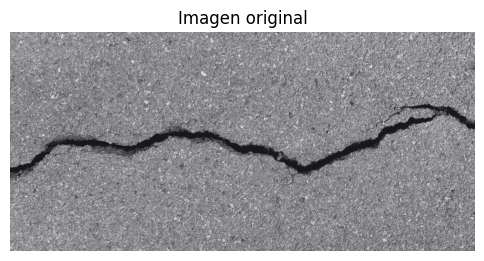

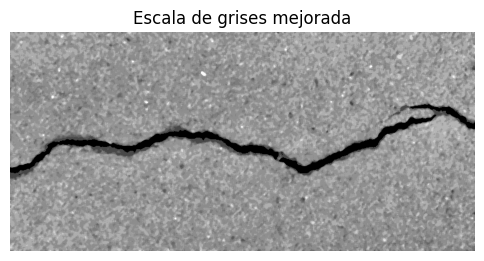

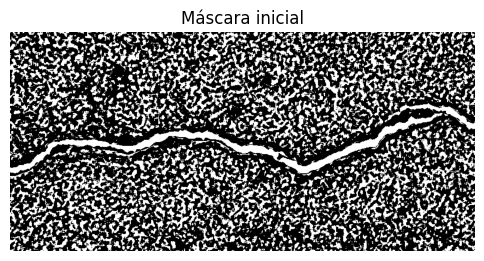

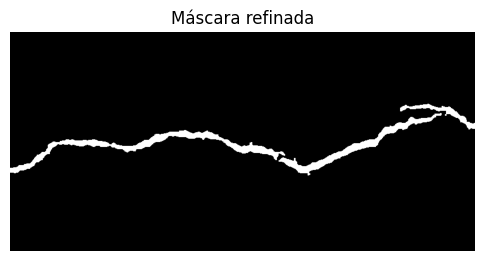

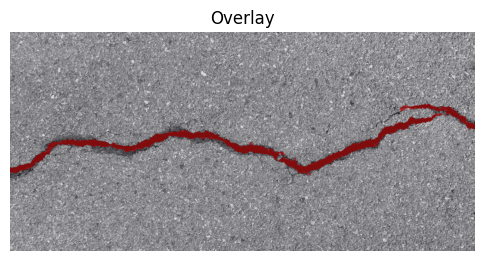

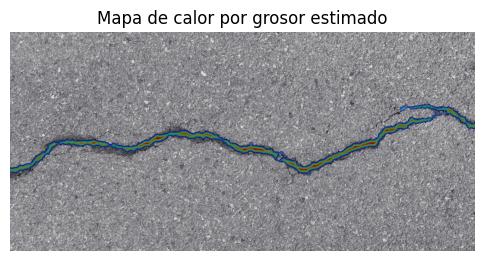

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# GretaVision - MVP en Colab

# 1. Instalar dependencias
!pip -q install opencv-python scikit-image pandas matplotlib

# 2. Importar librerías
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from skimage.morphology import skeletonize

def show(title, img, cmap=None):
    plt.figure(figsize=(6, 4))
    plt.title(title)
    plt.axis("off")
    plt.imshow(img, cmap=cmap)
    plt.show()

# 3. Subir imagen
uploaded = files.upload()
image_name = list(uploaded.keys())[0]

arr = np.frombuffer(uploaded[image_name], np.uint8)
bgr = cv2.imdecode(arr, cv2.IMREAD_COLOR)
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

show("Imagen original", rgb)

# 4. Preprocesamiento
gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
denoised = cv2.medianBlur(gray, 5)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced = clahe.apply(denoised)

show("Escala de grises mejorada", enhanced, cmap="gray")

# 5. Segmentación por umbral adaptativo
mask_raw = cv2.adaptiveThreshold(
    enhanced,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    31,
    5
)

show("Máscara inicial", mask_raw, cmap="gray")

# 6. Postprocesamiento
kernel = np.ones((3, 3), np.uint8)
opened = cv2.morphologyEx(mask_raw, cv2.MORPH_OPEN, kernel, iterations=1)
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=1)

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(closed, connectivity=8)

min_area = 250
mask_clean = np.zeros_like(mask_raw)

min_width = 40
min_height = 3
min_aspect_ratio = 2.5

mask_clean = np.zeros_like(mask_raw)

for label_id in range(1, num_labels):
    area = stats[label_id, cv2.CC_STAT_AREA]
    x = stats[label_id, cv2.CC_STAT_LEFT]
    y = stats[label_id, cv2.CC_STAT_TOP]
    w = stats[label_id, cv2.CC_STAT_WIDTH]
    h = stats[label_id, cv2.CC_STAT_HEIGHT]

    aspect_ratio = w / max(h, 1)

    if area >= min_area and w >= min_width and h >= min_height and aspect_ratio >= min_aspect_ratio:
        mask_clean[labels == label_id] = 255

show("Máscara refinada", mask_clean, cmap="gray")

# 7. Métricas geométricas
binary = (mask_clean > 0).astype(np.uint8)
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)
distance = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
skeleton = skeletonize(binary.astype(bool))

rows = []
for label_id in range(1, num_labels):
    component = labels == label_id
    area = int(stats[label_id, cv2.CC_STAT_AREA])
    x = int(stats[label_id, cv2.CC_STAT_LEFT])
    y = int(stats[label_id, cv2.CC_STAT_TOP])
    w = int(stats[label_id, cv2.CC_STAT_WIDTH])
    h = int(stats[label_id, cv2.CC_STAT_HEIGHT])
    cx, cy = centroids[label_id]

    component_skel = skeleton & component
    length_px = int(np.count_nonzero(component_skel))

    widths = 2.0 * distance[component_skel]
    mean_width = float(widths.mean()) if widths.size else 0.0
    max_width = float(widths.max()) if widths.size else 0.0

    rows.append({
        "id": label_id,
        "area_px": area,
        "centroid_x": round(float(cx), 2),
        "centroid_y": round(float(cy), 2),
        "bbox_x": x,
        "bbox_y": y,
        "bbox_w": w,
        "bbox_h": h,
        "length_px": length_px,
        "mean_width_px": round(mean_width, 2),
        "max_width_px": round(max_width, 2),
    })

df = pd.DataFrame(rows)
df

# 8. Overlay
overlay = rgb.copy()
red = np.zeros_like(rgb)
red[..., 0] = 255

alpha = 0.45
mask_bool = mask_clean > 0
overlay[mask_bool] = ((1-alpha) * rgb[mask_bool] + alpha * red[mask_bool]).astype(np.uint8)

show("Overlay", overlay)

# 9. Heatmap de grosor estimado
heat = np.zeros_like(distance, dtype=np.uint8)

if np.any(mask_clean > 0):
    values = distance[mask_clean > 0]
    max_val = values.max() if values.size else 0
    if max_val > 0:
        heat = np.uint8(np.clip((distance / max_val) * 255, 0, 255))

heat_bgr = cv2.applyColorMap(heat, cv2.COLORMAP_JET)
heat_rgb = cv2.cvtColor(heat_bgr, cv2.COLOR_BGR2RGB)

heat_overlay = rgb.copy()
heat_overlay[mask_bool] = ((1-alpha) * rgb[mask_bool] + alpha * heat_rgb[mask_bool]).astype(np.uint8)

show("Mapa de calor por grosor estimado", heat_overlay)

# 10. Exportar CSV
df.to_csv("gretavision_metrics.csv", index=False)
files.download("gretavision_metrics.csv")
